In [37]:
import torchaudio
import torchaudio.transforms as transforms
import torch
import numpy as np
import matplotlib.pyplot as plt
import librosa

In [9]:
# 1. Load audio and extract LFCCs
y, sr = torchaudio.load('debussy.wav')


In [17]:
# 2. Define LFCC transform
# n_lfcc: number of coefficients to retain
# speckwargs: Spectrogram arguments (n_fft, hop_length)
lfcc_transform = transforms.LFCC(
    sample_rate=sr, n_lfcc=13, speckwargs={"n_fft": 1024, "hop_length": 512, "center": True})

In [18]:
# 3. Compute LFCC
lfcc_features = lfcc_transform(y)

In [19]:
lfcc_features.shape

torch.Size([1, 13, 1292])

In [20]:
# Delta Transform (computes 1st derivative)
# win_length=5 is a standard default
compute_delta = transforms.ComputeDeltas(win_length=5)

In [23]:
# Step B: Get Delta (Apply to LFCC)
delta_lfcc = compute_delta(lfcc_features)      # Shape: (channel, n_lfcc, time)

In [25]:
delta_lfcc.shape

torch.Size([1, 13, 1292])

In [26]:
# Step C: Get Delta-Delta (Apply to Delta)
delta2_lfcc = compute_delta(delta_lfcc)    # Shape: (channel, n_lfcc, time)

In [31]:
# 3. Combine features (Stacking 13 LFCC + 13 Delta + 13 Double Delta = 39)
lfcc_features_comb = torch.cat((lfcc_features, delta_lfcc, delta2_lfcc), dim=1)

In [32]:
lfcc_features_comb.shape

torch.Size([1, 39, 1292])

In [33]:
lfcc_features_comb_sq=lfcc_features_comb.squeeze(0)

In [34]:
lfcc_features_comb_sq.shape

torch.Size([39, 1292])

In [35]:
lfcc_features_comb_np=lfcc_features_comb_sq.detach().cpu().numpy()

In [36]:
lfcc_features_comb_np.shape

(39, 1292)

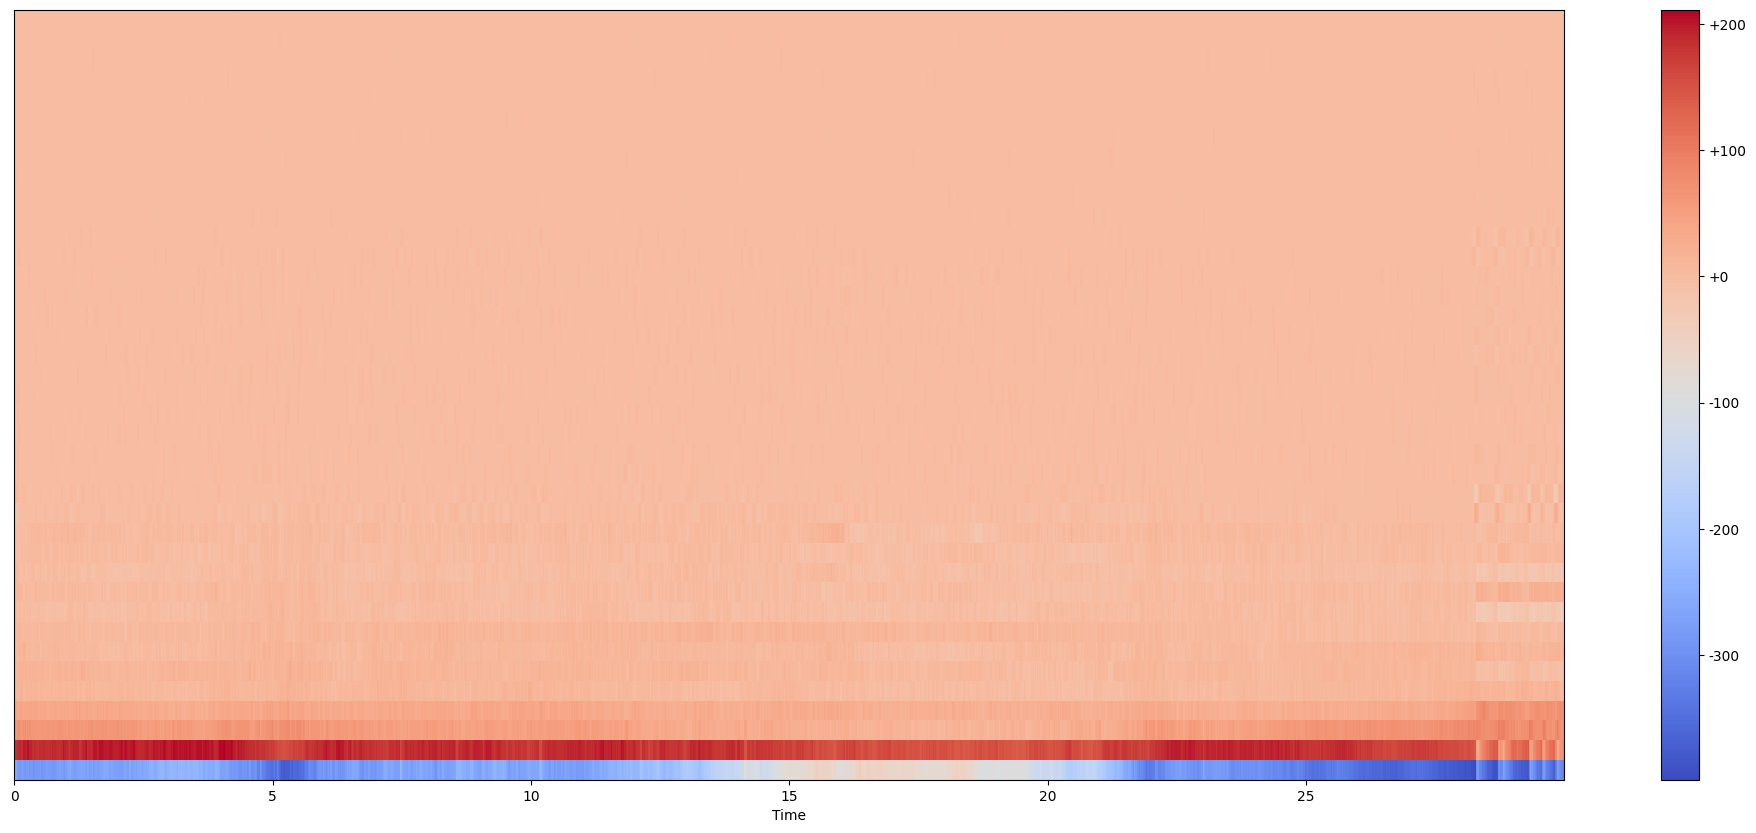

In [38]:
plt.figure(figsize=(25, 10))
librosa.display.specshow(lfcc_features_comb_np,
                         x_axis="time",
                         sr=sr)
plt.colorbar(format="%+2.f")
plt.show()


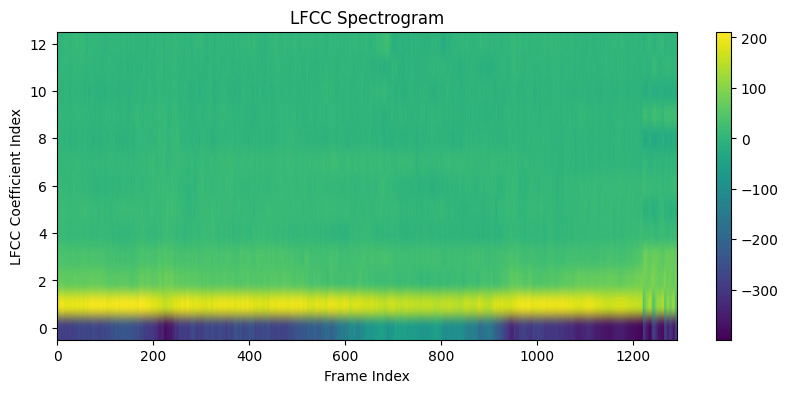

In [39]:
# 4. Plot
plt.figure(figsize=(10, 4))
plt.imshow(lfcc_features[0].detach().numpy(), aspect='auto', origin='lower')
plt.title('LFCC Spectrogram')
plt.ylabel('LFCC Coefficient Index')
plt.xlabel('Frame Index')
plt.colorbar()
plt.show()

In [40]:
lfcc_test=lfcc_features[0].detach().numpy()

In [41]:
lfcc_test.shape

(13, 1292)